In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')

print(df.shape)
print(df.head())

(1000, 9)
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [3]:
# getting rid of null values
print(df.isnull().sum())

for col in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [4]:
df = pd.get_dummies(df, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], drop_first=True, dtype=int)
print(df)

     Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0         522         7.93                    12                     1.0   
1         738        16.42                    20                     2.0   
2         741         9.52                    28                     1.0   
3         661         7.44                     5                     1.0   
4         412        19.03                    16                     5.0   
..        ...          ...                   ...                     ...   
995       107         8.50                    13                     3.0   
996       271        16.28                     8                     9.0   
997       861        15.62                    26                     2.0   
998       436        14.17                     8                     0.0   
999       103         6.63                    24                     3.0   

     Delivery_Time_min  Weather_Foggy  Weather_Rainy  Weather_Snowy  \
0               

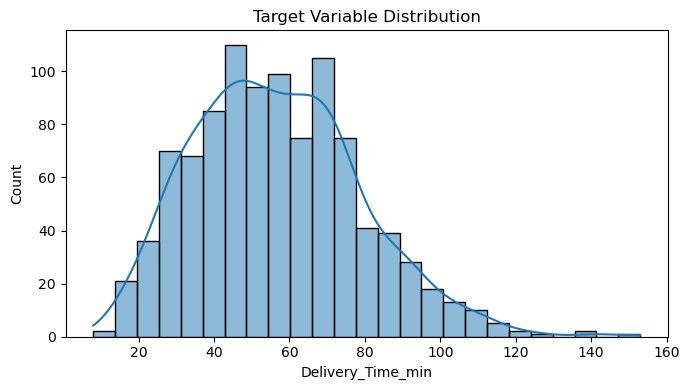

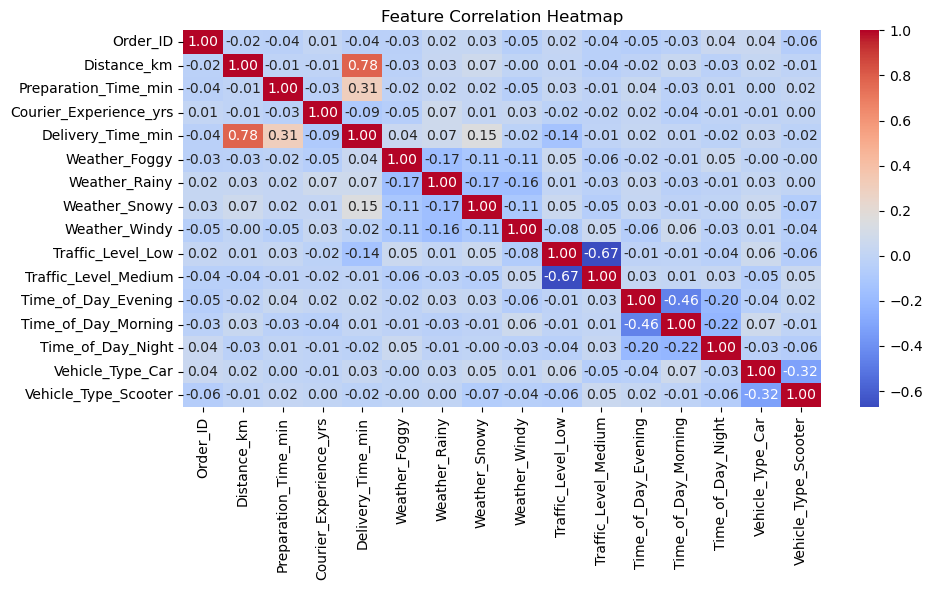

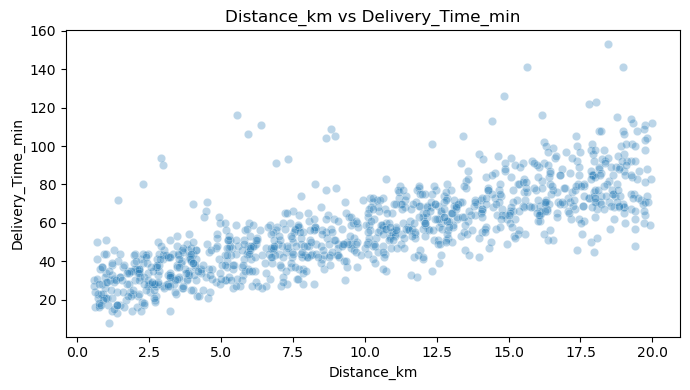

In [ ]:
target = 'Delivery_Time_min'

# plot 1: Distribution of target variable
plt.figure(figsize=(7, 4))
sns.histplot(df[target], kde=True)
plt.title('Target Variable Distribution')
plt.tight_layout()
plt.show()

# plot 2: Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap ')
plt.tight_layout()
plt.show()

# plot 3: Scatter plot
best_feature = df.corr()[target].drop(target).abs().idxmax()
plt.figure(figsize=(7, 4))
sns.scatterplot(x=df[best_feature], y=df[target], alpha=0.3)
plt.title(f'{best_feature} vs {target}')
plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (700, 15), Test size: (300, 15)


In [7]:
# model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [8]:
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"\n{name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAE  : {mae:.4f}")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest",     y_test, y_pred_rf)


Linear Regression
  RMSE : 9.2168
  R²   : 0.8303
  MAE  : 6.0604

Random Forest
  RMSE : 10.8516
  R²   : 0.7648
  MAE  : 7.3018
